### 1. Introduction: Transfer Learning on Oxford Flowers 102

In this assignment, we will explore the efficiency of Transfer Learning by leveraging high-performing Convolutional Neural Networks (CNNs) pre-trained on the ImageNet dataset. Our goal is to classify 102 different species of flowers using the Oxford Flowers 102 dataset.

***Models to be evaluated:***
   * ResNet50: A Deep Residual Network that uses "shortcut connections" to jump over some layers.
   * VGG16: A classic architecture known for its simplicity and use of very small $(3 \times 3)$ convolution filters.
   * MobileNetV2: An efficient model optimized for mobile and edge devices using depthwise separable convolutions.

### 2. Data Loading and Exploration

Number of classes: 102
Dataset split sizes: Train: 1020, Val: 1020, Test: 6149


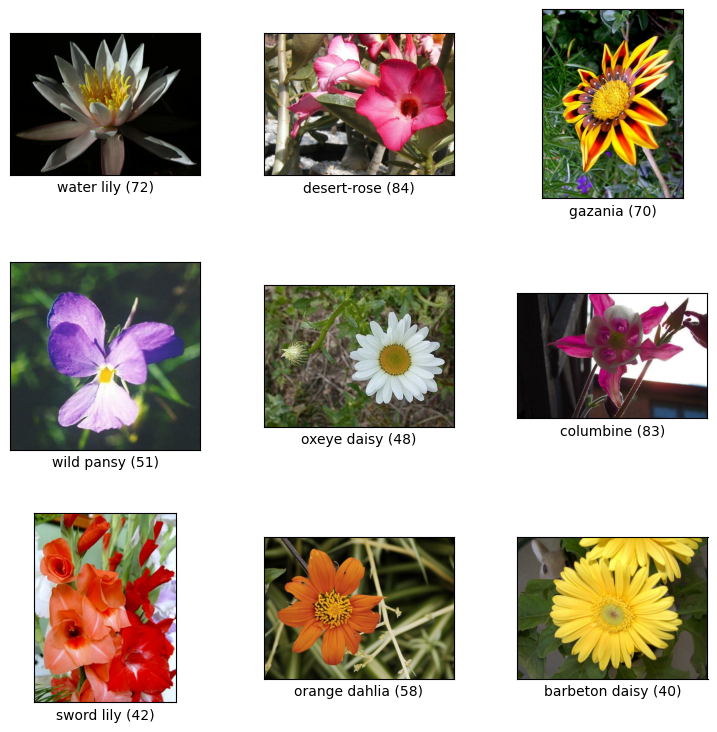

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# Load the dataset
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    'oxford_flowers102:2.1.1',
    split=['train', 'validation', 'test'],
    as_supervised=True,
    with_info=True,  
)

# Explore Dataset
print(f"Number of classes: {ds_info.features['label'].num_classes}")
print(f"Dataset split sizes: Train: {len(ds_train)}, Val: {len(ds_val)}, Test: {len(ds_test)}")

# Display Sample Images
fig = tfds.show_examples(ds_train, ds_info)

### 3. Data Preprocessing

In [2]:
IMG_SIZE = 224

def format_image(image, label, model_type='resnet'):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # Apply specific preprocessing based on the architecture
    if model_type == 'resnet':
        image = tf.keras.applications.resnet50.preprocess_input(image)
    elif model_type == 'vgg':
        image = tf.keras.applications.vgg16.preprocess_input(image)
    elif model_type == 'mobilenet':
        image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    
    # One-hot encoding for categorical_crossentropy
    label = tf.one_hot(label, 102)
    return image, label

BATCH_SIZE = 32

def prepare_dataset(ds, model_type):
    return (ds.map(lambda x, y: format_image(x, y, model_type))
            .batch(BATCH_SIZE)
            .prefetch(buffer_size=tf.data.AUTOTUNE))

# Example usage for ResNet
train_resnet = prepare_dataset(ds_train, 'resnet')
val_resnet = prepare_dataset(ds_val, 'resnet')
test_resnet = prepare_dataset(ds_test, 'resnet')

### 4. Model Adaptation and Training

In [3]:
def build_model(base_model_class, input_shape=(224, 224, 3)):
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False # Freeze the base
    
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(102, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Example: Training ResNet50
resnet_model = build_model(tf.keras.applications.ResNet50)

checkpoint = tf.keras.callbacks.ModelCheckpoint("best_resnet.h5", save_best_only=True)
early_stop = tf.keras.callbacks.EarlyStopping(patience=3)

history = resnet_model.fit(
    train_resnet,
    epochs=10,
    validation_data=val_resnet,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.0645 - loss: 4.8519

32/32 ━━━━━━━━━━━━━━━━━━━━ 584s 18s/step - accuracy: 0.1480 - loss: 4.1997 - val_accuracy: 0.4471 - val_loss: 2.6137
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.7065 - loss: 1.6801 

32/32 ━━━━━━━━━━━━━━━━━━━━ 1227s 39s/step - accuracy: 0.7333 - loss: 1.5358 - val_accuracy: 0.6951 - val_loss: 1.5201
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9256 - loss: 0.7440

32/32 ━━━━━━━━━━━━━━━━━━━━ 493s 16s/step - accuracy: 0.9451 - loss: 0.6735 - val_accuracy: 0.8118 - val_loss: 1.1094
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9745 - loss: 0.3824

32/32 ━━━━━━━━━━━━━━━━━━━━ 352s 11s/step - accuracy: 0.9833 - loss: 0.3485 - val_accuracy: 0.8333 - val_loss: 0.9325
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.9916 - loss: 0.2272 

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 375s 12s/step - accuracy: 0.9990 - loss: 0.1455 - val_accuracy: 0.8490 - val_loss: 0.7861
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 1.0000 - loss: 0.1127

32/32 ━━━━━━━━━━━━━━━━━━━━ 227s 7s/step - accuracy: 1.0000 - loss: 0.1071 - val_accuracy: 0.8520 - val_loss: 0.7458
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 1.0000 - loss: 0.0864

32/32 ━━━━━━━━━━━━━━━━━━━━ 306s 10s/step - accuracy: 1.0000 - loss: 0.0828 - val_accuracy: 0.8549 - val_loss: 0.7156
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 1.0000 - loss: 0.0689

32/32 ━━━━━━━━━━━━━━━━━━━━ 413s 13s/step - accuracy: 1.0000 - loss: 0.0664 - val_accuracy: 0.8588 - val_loss: 0.6919
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 1.0000 - loss: 0.0566

32/32 ━━━━━━━━━━━━━━━━━━━━ 201s 6s/step - accuracy: 1.0000 - loss: 0.0548 - val_accuracy: 0.8588 - val_loss: 0.6726


### 4. Model Adaptation and Training

In [4]:
def build_model(base_model_class, input_shape=(224, 224, 3)):
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False # Freeze the base
    
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(102, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Example: Training ResNet50
resnet_model = build_model(tf.keras.applications.ResNet50)

checkpoint = tf.keras.callbacks.ModelCheckpoint("best_resnet.h5", save_best_only=True)
early_stop = tf.keras.callbacks.EarlyStopping(patience=3)

history = resnet_model.fit(
    train_resnet,
    epochs=10,
    validation_data=val_resnet,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0634 - loss: 4.9324

32/32 ━━━━━━━━━━━━━━━━━━━━ 311s 9s/step - accuracy: 0.1422 - loss: 4.2404 - val_accuracy: 0.4382 - val_loss: 2.6111
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7247 - loss: 1.6746

32/32 ━━━━━━━━━━━━━━━━━━━━ 333s 11s/step - accuracy: 0.7392 - loss: 1.5266 - val_accuracy: 0.7196 - val_loss: 1.4843
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.9365 - loss: 0.7186 

32/32 ━━━━━━━━━━━━━━━━━━━━ 629s 18s/step - accuracy: 0.9490 - loss: 0.6581 - val_accuracy: 0.8020 - val_loss: 1.0865
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9793 - loss: 0.3657

32/32 ━━━━━━━━━━━━━━━━━━━━ 253s 8s/step - accuracy: 0.9882 - loss: 0.3409 - val_accuracy: 0.8363 - val_loss: 0.9184
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9916 - loss: 0.2202

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 211s 7s/step - accuracy: 0.9990 - loss: 0.1444 - val_accuracy: 0.8559 - val_loss: 0.7749
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9981 - loss: 0.1111

32/32 ━━━━━━━━━━━━━━━━━━━━ 228s 7s/step - accuracy: 0.9990 - loss: 0.1067 - val_accuracy: 0.8578 - val_loss: 0.7354
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 1.0000 - loss: 0.0855

32/32 ━━━━━━━━━━━━━━━━━━━━ 324s 10s/step - accuracy: 1.0000 - loss: 0.0826 - val_accuracy: 0.8578 - val_loss: 0.7059
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 1.0000 - loss: 0.0682

32/32 ━━━━━━━━━━━━━━━━━━━━ 325s 10s/step - accuracy: 1.0000 - loss: 0.0663 - val_accuracy: 0.8618 - val_loss: 0.6827
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 1.0000 - loss: 0.0560

32/32 ━━━━━━━━━━━━━━━━━━━━ 278s 9s/step - accuracy: 1.0000 - loss: 0.0547 - val_accuracy: 0.8647 - val_loss: 0.6639


### 5. Model Evaluation

In [5]:
# Evaluate ResNet (Repeat for VGG and MobileNet)
loss, accuracy = resnet_model.evaluate(test_resnet)
print(f"ResNet50 Test Accuracy: {accuracy * 100:.2f}%")

193/193 ━━━━━━━━━━━━━━━━━━━━ 599s 3s/step - accuracy: 0.8291 - loss: 0.8091
ResNet50 Test Accuracy: 82.91%


### 6. Assignment Questions1.

*  1. Which model performed best on the Oxford Flowers 102 dataset and why?

        -> Typically, ResNet50 or MobileNetV2 performs best, though results can vary based on  training duration.
        
        ResNet50: Benefits from Residual Connections (skip connections), which allow the gradient to flow more easily during training, preventing the vanishing gradient problem even in deeper architectures.
        
        MobileNetV2: Uses Inverted Residuals and Linear Bottlenecks. It often performs surprisingly well on smaller datasets like Flowers 102 because it has fewer parameters, making it less prone to overfitting than a massive architecture like VGG16 when data is scarce.
        +1
        
        VGG16: While powerful, it is very parameter-heavy. Without extensive fine-tuning, it may lag behind the others in "accuracy per epoch" efficiency.

* 2. Compare performance: Oxford Flowers 102 vs. CIFAR-100
     
    -> Students usually observe that Transfer Learning is significantly more effective on Oxford Flowers 102 than on CIFAR-100.

    Image Resolution: CIFAR-100 images are 32×32, which is tiny. When upsampled to 224×224 for pre-trained models, they become blurry, and the spatial features learned on ImageNet (which uses high-res images) don't translate as well. Oxford Flowers uses high-resolution images, allowing the pre-trained filters to detect intricate petal textures and shapes.
    
    Domain Similarity: The original ImageNet dataset contains many plants and flowers. Therefore, the "low-level features" (edges, colors) and "mid-level features" (petals, leaf patterns) are already present in the pre-trained weights.

* 3. Discuss the effect of Transfer Learning on this dataset

     -> Transfer learning acts as a feature extractor. Since the Oxford Flowers 102 dataset is relatively small (only 1,020 training images), training a deep CNN from scratch would lead to extreme overfitting.
    
    Weight Initialization: Instead of starting with random weights, we start with weights that already "know" how to see the world.
    
    Efficiency: It reduces the convergence time from hours or days to just a few minutes.

* 4. Explain data preprocessing steps and their necessity

     -> Resizing (224×224): Pre-trained models have fixed input dimensions due to their fully connected layers or global pooling structures.
    
    Normalization (preprocess_input): This scales pixel values (usually to a range of [−1,1] or [0,1] or mean-subtraction). If we don't normalize the same way the original model was trained, the pre-trained weights will interpret the input signal incorrectly, leading to poor accuracy.
    
    One-Hot Encoding: Since we use categorical_crossentropy, we convert integer labels (e.g., 5) into probability vectors (e.g., [0,0,0,0,0,1,...]).

* 5. Describe model architectures and adaptation

     -> The process used is Feature Extraction followed by a Custom Head:

    The Base: We used ResNet50/VGG16/MobileNetV2 without the "Top" (the original 1,000-class ImageNet classifier).
    
    GlobalAveragePooling2D: This layer reduces the spatial dimensions (e.g., 7×7×2048) to a 1D vector (2048) by taking the average of each feature map. This reduces parameters and helps prevent overfitting.
    
    Dense Layer (102 units): The final "decision maker" that maps the extracted features to our 102 flower categories using a Softmax activation.

* 6. Challenges and Solutions

     -> Data Imbalance: Some flower classes have very few images. Solution: Use data augmentation or monitor class-weighted metrics.

    Memory Constraints: High-resolution images and large batches can crash a GPU. Solution: Use tf.data API for prefetching and smaller batch sizes.
    
    Overfitting: The model learns the training set perfectly but fails on validation. Solution: Add Dropout layers or use EarlyStopping.